## Dictionary: Please read before running code and editing/commenting

1. Hypothesis:
An LSTM model will improve heat vulnerability prediction in NYC by classifying ZIP-code-days into five vulnerability levels using recent temporal patterns in temperature, 311 heat complaints, infrastructure, density, population, and energy usage.

2. Machine learning formulation:
This project is a supervised multi-class classification task. The model predicts a project-defined temporal heat vulnerability class for each ZIP-code-day.

3. Input (X):
For the LSTM, each input is a 7-day sequence of ZIP-code-level observations. Each day includes seven features: 311 heat complaint count, maximum temperature, street tree count, population density, population, water fountain count, and natural gas usage. For the baseline models, the same seven features are used as single-day flat observations.

4. Output (Y):
The output is a temporal heat vulnerability class from 1 lowest to 5 highest. This label is constructed by creating a composite daily risk signal and binning it into five percentile-based classes. The official NYC HVI is not the direct prediction target. Instead, it is used as a reference benchmark for interpretation.

5. Objective function:
to minimize classification error across the five temporal heat vulnerability classes.

6. Primary deep learning component:
The final model is an LSTM with a 7-day lookback window, dropout regularization, and a softmax output layer. The LSTM is the core deep learning component because it processes ordered daily sequences and can retain information from prior days when classifying current heat vulnerability.

7. Why LSTM:
A single-day model treats each ZIP-code-day as independent. The LSTM instead receives a sequence of recent observations, allowing it to learn whether vulnerability depends on cumulative heat exposure, lagged complaint patterns, or multi-day infrastructure and energy-use signals. This directly tests whether temporal structure improves heat vulnerability prediction.

8. Baseline models:
Decision Tree, Random Forest, and XGBoost are used as non-temporal baselines. They use the same feature set but flatten the data into single-day observations, so they serve as cross-sectional benchmarks against the sequence-based LSTM.

9. Evaluation metrics:
Accuracy, Macro F1, Weighted F1, and Mean Absolute Class Error are evaluated on a held-out 2025 temporal test set. Accuracy measures overall correctness, Macro F1 checks performance across classes more evenly, Weighted F1 accounts for class imbalance, and Mean Absolute Class Error measures how far off predictions are on the 1–5 ordinal vulnerability scale.

10. Ablation or sensitivity analysis:
We compare LSTM performance across different lookback windows, such as 1 day, 3 days, 7 days, and 14 days.

11. Core project contribution:
This project investigates whether temporal sequence modeling improves dynamic vulnerability classification compared with strong non-temporal baselines.



In [3]:
import numpy as np
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from google.colab import files
uploaded = files.upload()

import os
import shutil
import pandas as pd

os.makedirs("data", exist_ok=True)
shutil.move("data_NAandSteamOmitted.csv", "data/data_NAandSteamOmitted.csv")

df = pd.read_csv("data/data_NAandSteamOmitted.csv")
df.head()

Saving data_NAandSteamOmitted.csv to data_NAandSteamOmitted.csv


,Unnamed: 0,zip,date,call_count,HVI,fountains,gas_therms,tree_count,population_density,population,max_temp
0,1,10001,2018-05-15,0,2,15,16971904,911,26111.88,17310,76
1,2,10001,2018-05-16,0,2,15,16971904,911,26111.88,17310,65
2,3,10001,2018-05-17,0,2,15,16971904,911,26111.88,17310,67
3,4,10001,2018-05-18,0,2,15,16971904,911,26111.88,17310,64
4,5,10001,2018-05-19,0,2,15,16971904,911,26111.88,17310,57


In [4]:
# Dataset inspection
print(df.columns.tolist())
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

# prep data formats
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

['Unnamed: 0', 'zip', 'date', 'call_count', 'HVI', 'fountains', 'gas_therms', 'tree_count', 'population_density', 'population', 'max_temp']
(163515, 11)
   Unnamed: 0    zip        date  call_count  HVI  fountains  gas_therms  \
0           1  10001  2018-05-15           0    2         15    16971904   
1           2  10001  2018-05-16           0    2         15    16971904   
2           3  10001  2018-05-17           0    2         15    16971904   
3           4  10001  2018-05-18           0    2         15    16971904   
4           5  10001  2018-05-19           0    2         15    16971904   

   tree_count  population_density  population  max_temp  
0         911            26111.88       17310        76  
1         911            26111.88       17310        65  
2         911            26111.88       17310        67  
3         911            26111.88       17310        64  
4         911            26111.88       17310        57  
<class 'pandas.core.frame.DataFrame'>
Rang

## Building Models (Decision Tree, Random Forest, XGBoost)

In [5]:
# ============================================================
# 1. CREATE TEMPORAL HVI TARGET (FEATURE-DRIVEN, 1-5 SCALE)
# This target is intentionally independent of original HVI.
# Modeling scope: 2020-2025 only (currently lacking 311 data from 2018-2019)
# ============================================================

model_df = df[df['year'].between(2020, 2025)].copy()
print(f"Modeling rows kept (2020-2025): {len(model_df):,}")

FEATURES = [
    'call_count',         # daily 311 calls
    'max_temp',           # daily temperature maximum
    'tree_count',         # street trees - static per ZIP
    'population_density', # population density - static per ZIP
    'population',         # population - static per ZIP
    'fountains',          # water fountains - static per ZIP
    'gas_therms'          # natural gas usage - proxy for AC usage
]

X_raw = model_df[FEATURES].copy()

# build a risk signal from features (NOT from original HVI) to order clusters
risk_features = ['call_count', 'max_temp', 'population_density', 'gas_therms']
risk_norm = (
    X_raw[risk_features] - X_raw[risk_features].min()
 ) / (X_raw[risk_features].max() - X_raw[risk_features].min())
risk_norm = risk_norm.fillna(0)
model_df['temporal_risk_signal'] = risk_norm.mean(axis=1)

# temporal HVI target using percentile-based binning
# for future iterations of this model, we can change binning strategy (to avoid uniform distribution of output HVI classes)
model_df['temporal_hvi_target'] = pd.qcut(
    model_df['temporal_risk_signal'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)


Modeling rows kept (2020-2025): 122,595


In [6]:
# ============================================================
# 2. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# 80% train, 10% validation, 10% test
# Using 2020-2025 data only, random within HVI strata
# ============================================================
X = model_df[FEATURES]
y = model_df['temporal_hvi_target'] - 1

# splitting training data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# splitting validation and test data from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\nRandom split complete (stratified by temporal_hvi classes).")
print(
    f"Train size: {len(X_train):,} | Val size: {len(X_val):,} | Test size: {len(X_test):,}"
)


Random split complete (stratified by temporal_hvi classes).
Train size: 98,076 | Val size: 12,259 | Test size: 12,260


In [7]:
# ============================================================
# 3. MODELS FOR TEMPORAL HVI CLASSIFICATION
# Decision Tree: Hannah's suggestion, most interpretable, can overfit
# Random Forest: Hannah's suggestion, most stable, gives feature importance
# XGBoost: Jacob's suggestion, typically most accurate
# ============================================================
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=5, ...)

In [8]:
# ============================================================
# 4. EVALUATION ON VALIDATION + TEST DATA
# for the prototype, we are not tuning hyperparameters
# ============================================================
label_order = [0, 1, 2, 3, 4]
target_names = ['1', '2', '3', '4', '5']
models = [('Decision Tree', dt), ('Random Forest', rf), ('XGBoost', xgb)]

for name, model in models:
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    print(f"\n{name} - Validation")
    print(classification_report(
        y_val, y_val_pred, labels=label_order, target_names=target_names, zero_division=0
    ))

    print(f"{name} - Test")
    print(classification_report(
        y_test, y_test_pred, labels=label_order, target_names=target_names, zero_division=0
    ))



Decision Tree - Validation
              precision    recall  f1-score   support

           1       0.91      0.84      0.88      2452
           2       0.65      0.84      0.74      2451
           3       0.60      0.57      0.58      2452
           4       0.66      0.59      0.62      2452
           5       0.87      0.83      0.85      2452

    accuracy                           0.73     12259
   macro avg       0.74      0.73      0.73     12259
weighted avg       0.74      0.73      0.73     12259

Decision Tree - Test
              precision    recall  f1-score   support

           1       0.92      0.84      0.88      2452
           2       0.66      0.83      0.74      2452
           3       0.60      0.58      0.59      2452
           4       0.66      0.60      0.63      2452
           5       0.88      0.83      0.85      2452

    accuracy                           0.74     12260
   macro avg       0.74      0.74      0.74     12260
weighted avg       0.74     

## Visualizing, Comparing, and Ground-Truthing Models

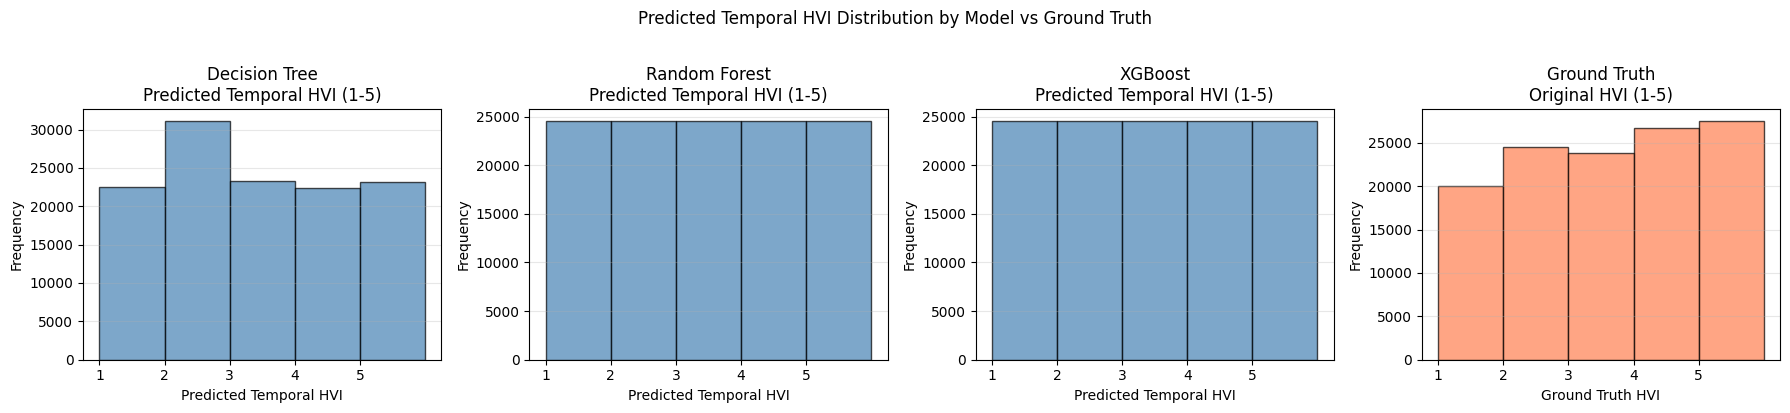

In [9]:
# ============================================================
# 5. FINAL TEMPORAL HVI PREDICTIONS (ALL MODELS)
# ============================================================
model_df['predicted_temporal_hvi_dt'] = dt.predict(X).astype(int) + 1
model_df['predicted_temporal_hvi_rf'] = rf.predict(X).astype(int) + 1
model_df['predicted_temporal_hvi_xgb'] = xgb.predict(X).astype(int) + 1

# Keep this alias for compatibility with downstream cells.
model_df['predicted_temporal_hvi'] = model_df['predicted_temporal_hvi_xgb']

# Visualization: Distribution of predicted temporal HVI for all three models + ground truth with non-temporal HVI
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (model_col, label) in zip(
    axes[:3],
    [
        ('predicted_temporal_hvi_dt', 'Decision Tree'),
        ('predicted_temporal_hvi_rf', 'Random Forest'),
        ('predicted_temporal_hvi_xgb', 'XGBoost'),
    ]
):
    ax.hist(model_df[model_col], bins=range(1, 7), alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel('Predicted Temporal HVI')
    ax.set_ylabel('Frequency')
    ax.set_xticks(range(1, 6))
    ax.set_title(f'{label}\nPredicted Temporal HVI (1-5)')
    ax.grid(True, alpha=0.3, axis='y')

# Ground truth distribution panel
ax = axes[3]
ax.hist(model_df['HVI'].clip(1, 5).round(), bins=range(1, 7), alpha=0.7, color='coral', edgecolor='black')
ax.set_xlabel('Ground Truth HVI')
ax.set_ylabel('Frequency')
ax.set_xticks(range(1, 6))
ax.set_title('Ground Truth\nOriginal HVI (1-5)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Predicted Temporal HVI Distribution by Model vs Ground Truth', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Mean final prediction by ZIP for each model (for comparison to original HVI later)
mean_pred_hvi = (
    model_df.groupby('zip', as_index=False)
      .agg(
          mean_temporal_hvi_dt=('predicted_temporal_hvi_dt', 'mean'),
          mean_temporal_hvi_rf=('predicted_temporal_hvi_rf', 'mean'),
          mean_temporal_hvi_xgb=('predicted_temporal_hvi_xgb', 'mean')
      )
      .sort_values('mean_temporal_hvi_xgb', ascending=False)
      .reset_index(drop=True)
)


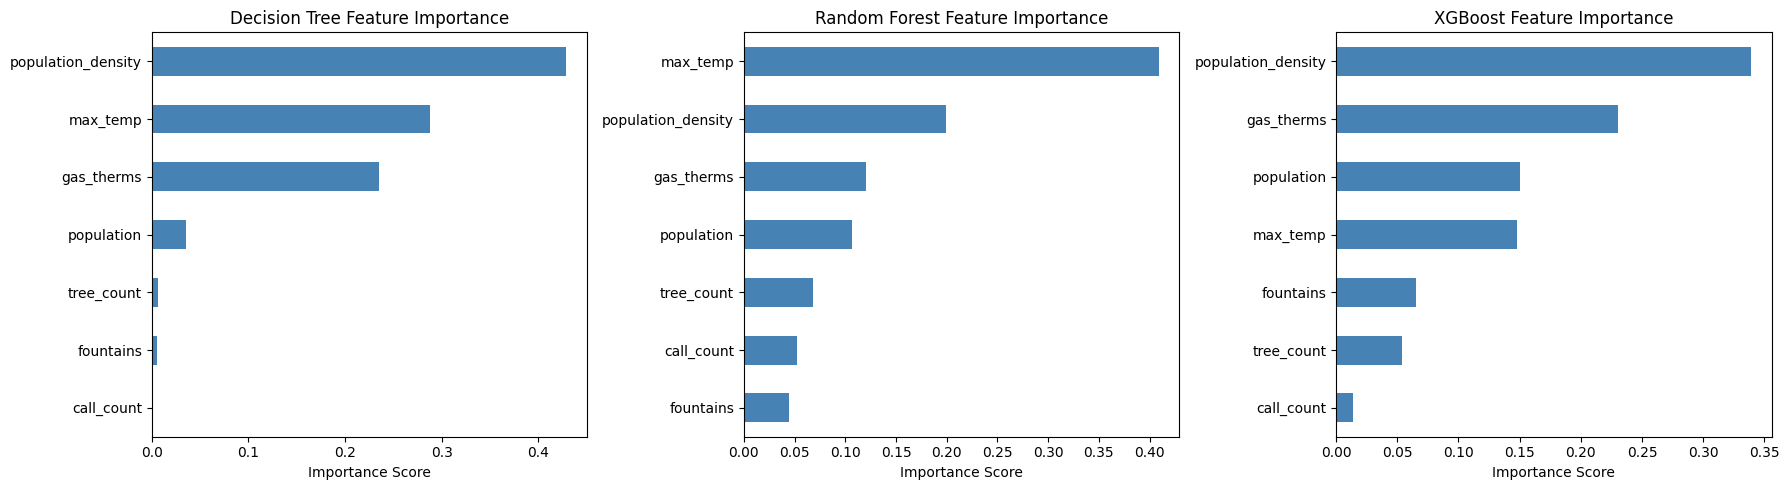

In [10]:
# ============================================================
# 6. FEATURE IMPORTANCE COMPARISON ACROSS MODELS
# to see which features are most influential for each model's predictions
# ============================================================
importance_frames = [
    ('Decision Tree', pd.Series(dt.feature_importances_, index=FEATURES)),
    ('Random Forest', pd.Series(rf.feature_importances_, index=FEATURES)),
    ('XGBoost', pd.Series(xgb.feature_importances_, index=FEATURES))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for ax, (model_name, imp) in zip(axes, importance_frames):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{model_name} Feature Importance')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

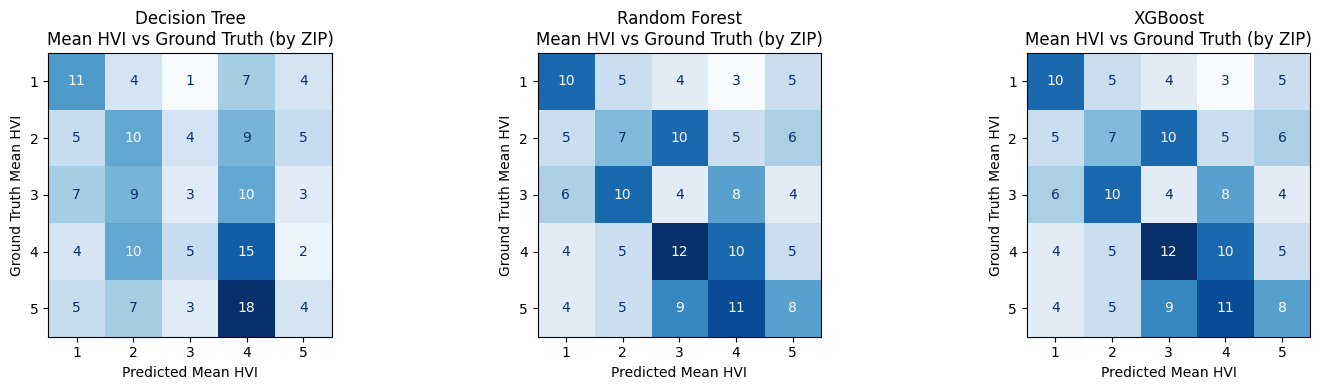

In [11]:
# ============================================================
# 7. MEAN HVI COMPARISON: MODELS vs GROUND TRUTH
# seeing how temporally averaged HVI predictions compare to mean original HVI by ZIP
# ============================================================
# Get ground truth: mean original HVI per ZIP (from 2020-2025 subset)
ground_truth_hvi = (
    model_df.groupby('zip', as_index=False)
      .agg(ground_truth_hvi=('HVI', lambda x: x.clip(1, 5).round().mean()))
)

# Merge ground truth with model predictions
comparison_df = mean_pred_hvi.merge(ground_truth_hvi, on='zip', how='left')

# Confusion matrices: each model's mean prediction vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_col, label) in zip(
    axes,
    [
        ('mean_temporal_hvi_dt', 'Decision Tree'),
        ('mean_temporal_hvi_rf', 'Random Forest'),
        ('mean_temporal_hvi_xgb', 'XGBoost'),
    ]
):
    # Bin predictions and ground truth to 1-5 integer scale using ceil for model predictions
    pred_binned = round(comparison_df[model_col]).astype(int).clip(1, 5)
    truth_binned = comparison_df['ground_truth_hvi'].round().astype(int).clip(1, 5)

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        truth_binned,
        pred_binned,
        labels=[1, 2, 3, 4, 5],
        display_labels=['1', '2', '3', '4', '5'],
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f"{label}\nMean HVI vs Ground Truth (by ZIP)")
    ax.set_xlabel("Predicted Mean HVI")
    ax.set_ylabel("Ground Truth Mean HVI")

plt.tight_layout()
plt.show()



Top 3 ZIPs with highest variability in predicted HVI:
  ZIP 11375: avg std dev = 1.023
  ZIP 10475: avg std dev = 1.020
  ZIP 11210: avg std dev = 0.935


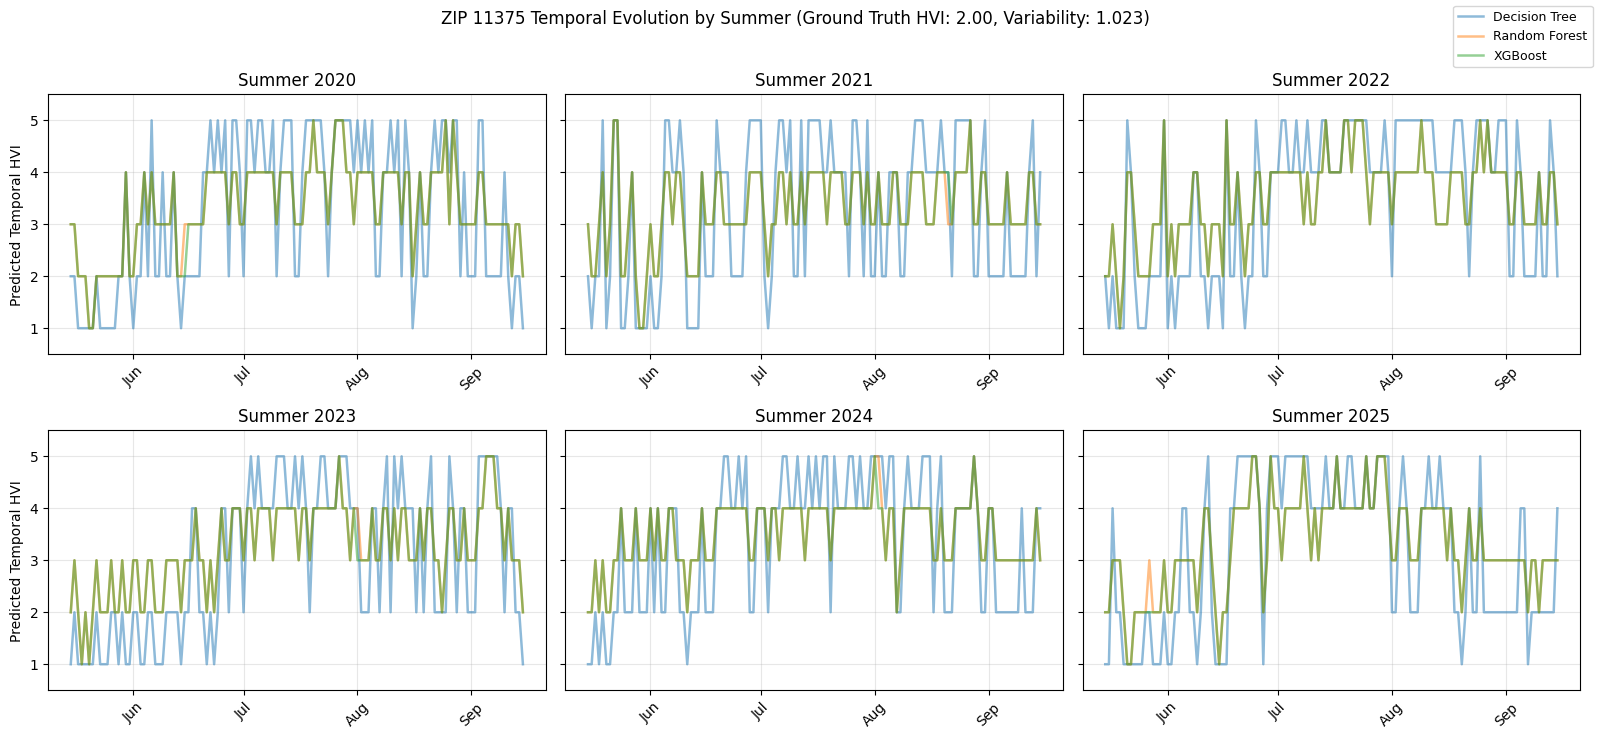

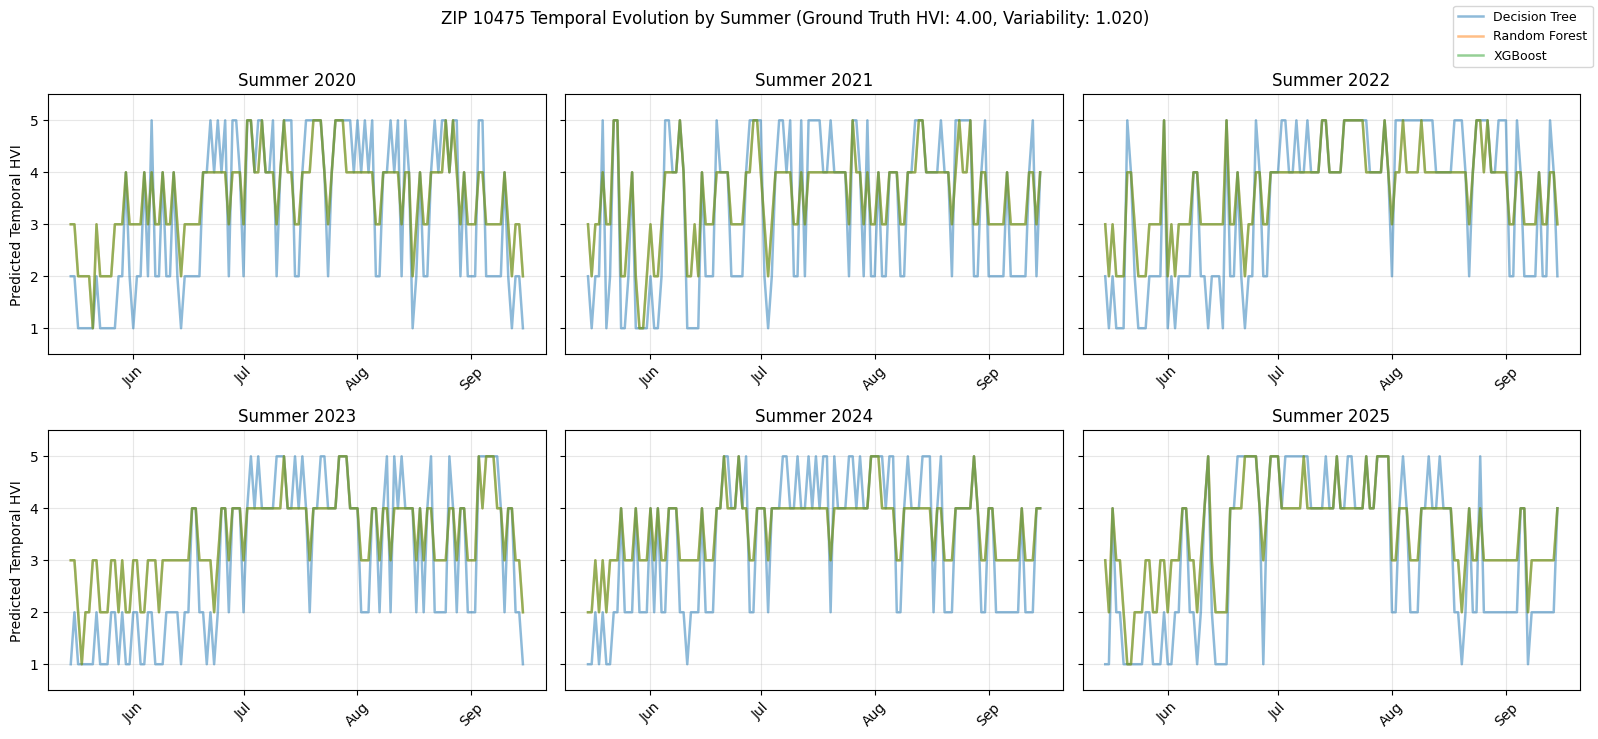

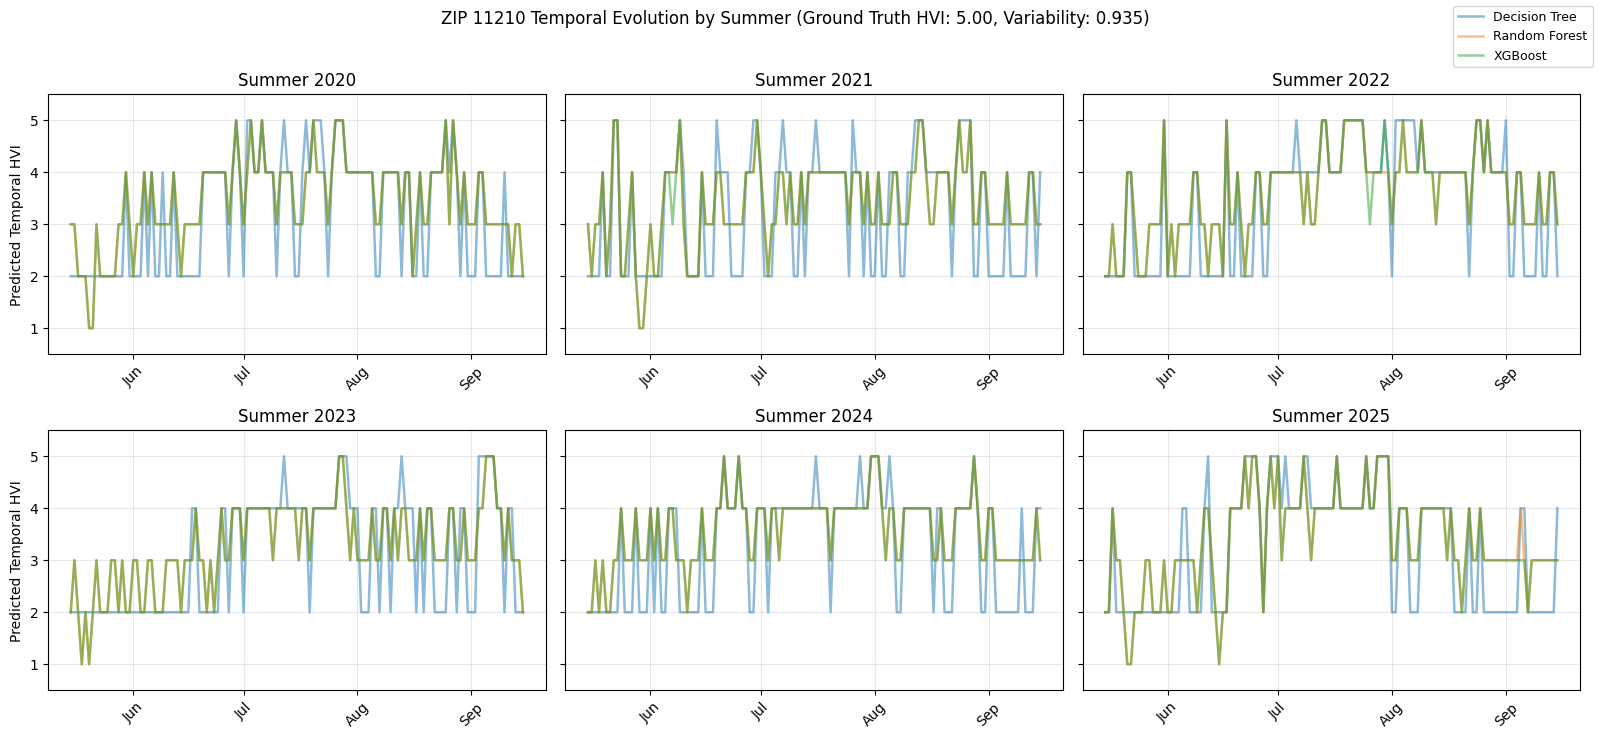

In [12]:
# ============================================================
# 8. TEMPORAL EVOLUTION: MODEL PREDICTIONS OVER TIME
# Plot top 3 ZIPs HVIs (monthly averages) by highest variability
# ============================================================
pred_cols = ['predicted_temporal_hvi_dt', 'predicted_temporal_hvi_rf', 'predicted_temporal_hvi_xgb']

# Calculate variability (std dev) of predicted HVI for each ZIP across observed dates
variability_df = (
    model_df.groupby('zip')[pred_cols]
      .std()
      .mean(axis=1)  # average variability across all three models
      .sort_values(ascending=False)
)

top_variable_zips = variability_df.head(3).index.tolist()
print(f"\nTop 3 ZIPs with highest variability in predicted HVI:")
for zip_code in top_variable_zips:
    print(f"  ZIP {zip_code}: avg std dev = {variability_df[zip_code]:.3f}")

# Restrict to selected ZIPs and prepare year for per-summer panels
summer_df = model_df[model_df['zip'].isin(top_variable_zips)].copy()
summer_df['year'] = summer_df['date'].dt.year

# Aggregate to daily means per ZIP/year/date in case there are multiple rows/day
zip_daily = (
    summer_df[['zip', 'year', 'date'] + pred_cols]
      .groupby(['zip', 'year', 'date'], as_index=False)
      .mean()
)

# Ground-truth lookup for titles (computed in prior comparison cell)
gt_lookup = comparison_df.set_index('zip')['ground_truth_hvi'].to_dict()

# One figure per ZIP, with one subplot per summer year (typically 2020-2025 => 6 subplots)
for zip_code in top_variable_zips:
    zip_yearly = zip_daily[zip_daily['zip'] == zip_code].copy()
    years = sorted(zip_yearly['year'].unique())

    n_cols = 3
    n_rows = int(np.ceil(len(years) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for i, year in enumerate(years):
        ax = axes[i]
        yearly = zip_yearly[zip_yearly['year'] == year].sort_values('date')

        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_dt'], linewidth=1.8, alpha = 0.5,label='Decision Tree')
        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_rf'], linewidth=1.8, alpha = 0.5, label='Random Forest')
        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_xgb'], linewidth=1.8, alpha = 0.5, label='XGBoost')

        ax.set_title(f'Summer {year}')
        ax.set_ylim(0.5, 5.5)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', rotation=45)

        if i % n_cols == 0:
            ax.set_ylabel('Predicted Temporal HVI')

    # Turn off any unused subplot slots
    for ax in axes[len(years):]:
        ax.axis('off')

    gt_hvi = gt_lookup.get(zip_code, np.nan)
    gt_str = f"{gt_hvi:.2f}" if pd.notna(gt_hvi) else "N/A"
    fig.suptitle(
        f"ZIP {zip_code} Temporal Evolution by Summer "
        f"(Ground Truth HVI: {gt_str}, Variability: {variability_df[zip_code]:.3f})",
        y=1.02,
        fontsize=12
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9)
    fig.tight_layout()
    plt.show()

In [13]:
# ============================================================
# 9. MODEL AGREEMENT: DO ALL THREE MODELS AGREE?
# ============================================================
# Compare pairwise disagreement between models
comparison_df['dt_rf_diff'] = (comparison_df['mean_temporal_hvi_dt'] - comparison_df['mean_temporal_hvi_rf']).abs()
comparison_df['dt_xgb_diff'] = (comparison_df['mean_temporal_hvi_dt'] - comparison_df['mean_temporal_hvi_xgb']).abs()
comparison_df['rf_xgb_diff'] = (comparison_df['mean_temporal_hvi_rf'] - comparison_df['mean_temporal_hvi_xgb']).abs()

print("\n=== Model Agreement Analysis ===")
print(f"Mean absolute difference (DT vs RF): {comparison_df['dt_rf_diff'].mean():.3f}")
print(f"Mean absolute difference (DT vs XGB): {comparison_df['dt_xgb_diff'].mean():.3f}")
print(f"Mean absolute difference (RF vs XGB): {comparison_df['rf_xgb_diff'].mean():.3f}")

# ZIPs with highest disagreement
comparison_df['max_disagreement'] = comparison_df[['dt_rf_diff', 'dt_xgb_diff', 'rf_xgb_diff']].max(axis=1)
print("\nZIPs with highest model disagreement:")
print(comparison_df.nlargest(5, 'max_disagreement')[['zip', 'ground_truth_hvi', 'mean_temporal_hvi_dt', 'mean_temporal_hvi_rf', 'mean_temporal_hvi_xgb', 'max_disagreement']])



=== Model Agreement Analysis ===
Mean absolute difference (DT vs RF): 0.233
Mean absolute difference (DT vs XGB): 0.233
Mean absolute difference (RF vs XGB): 0.002

ZIPs with highest model disagreement:
       zip  ground_truth_hvi  mean_temporal_hvi_dt  mean_temporal_hvi_rf  \
14   11201               2.0              3.550471              4.819650   
18   11224               5.0              3.550471              4.703903   
106  10034               1.0              3.555855              2.423957   
20   10456               5.0              3.617766              4.652759   
100  10017               2.0              3.555855              2.590848   

     mean_temporal_hvi_xgb  max_disagreement  
14                4.815612          1.269179  
18                4.705249          1.154778  
106               2.422611          1.133244  
20                4.648721          1.034993  
100               2.580081          0.975774  


##New Model: LSTM & Why it Helps our Project

Projec's problem: the existing NYC Heat Vulnerability Index (HVI) is valuable but static. By "static," we mean that the HVI identifies which neighborhoods are generally more vulnerable to heat, but it does not update day by day as conditions change. In practice, this means that an area’s official vulnerability score may not fully capture short-term changes in temperature, complaints, infrastructure stress, or other daily signals.

Project's model: an ML feature called Long Short Termm Memory to move from a static HVI framework toward a dynamic prediction tool: instead of assigning each ZIP code a fixed vulnerability score, the model predicts a daily temporal HVI category using recent ZIP-code-level data.



## Chunk 1 Notes: 1st LSTM attempt

**High-level explanation:** Here it is our LSTM model... at least the first attempt! Instead of asking only what a ZIP code’s vulnerability looks like on 1 isolated day, the model asks whether recent patterns over the previous several days can help predict the current day’s temporal HVI category. This matters because the project’s main problem, and subequent contribution to the literature, is that the official HVI is useful but static. This LSTM addresses this limitation by learning from sequences of ZIP-code-level observations. In other words, we use recent historical signals — including heat complaints, temperature, tree coverage, population density, population, water fountain access, and gas usage — to classify each ZIP code’s current temporal heat vulnerability level from 1 to 5. The code also evaluates how well the LSTM performs using a held-out test set, classification metrics, a confusion matrix, and training history plots.

**Technical explantation:**
1. Code first prepares the dataset by copying model_df, converting the date column into a datetime format, converting ZIP codes into strings, and recoding the target variable temporal_hvi_target from a 1–5 scale into a 0–4 scale, which is required for TensorFlow’s sparse categorical classification loss.
2. Then it removes rows with missing values in the selected feature columns or target variable and sorts the data by ZIP code and date.
3. The code creates a temporal train-validation-test split, using observations through 2023 for training, 2024 for validation, and 2025 for testing; this is more rigorous than a random split because it evaluates whether the model can generalize to later time periods. The feature variables are standardized using StandardScaler, with the scaler fit only on the training set to avoid data leakage.
4. The key LSTM-specific step is the create_sequences() function, which groups the data by ZIP code and transforms the flat dataset into three-dimensional input tensors. Each input sequence has shape 7 × 7, meaning seven prior ZIP-code-day observations and seven features per day.
5. The model then uses an LSTM layer with 64 units, dropout regularization, a dense hidden layer, and a five-unit softmax output layer to predict one of five temporal HVI classes.
7. It is trained with sparse categorical cross-entropy loss and Adam optimization, while early stopping monitors validation loss and restores the best-performing model weights. Finally, the code predicts temporal HVI categories on the test set, computes accuracy, macro F1, and weighted F1, and visualizes performance through a confusion matrix and training/validation accuracy and loss curves.

model_df shape: (122595, 19)
FEATURES: ['call_count', 'max_temp', 'tree_count', 'population_density', 'population', 'fountains', 'gas_therms']
Columns: ['Unnamed: 0', 'zip', 'date', 'call_count', 'HVI', 'fountains', 'gas_therms', 'tree_count', 'population_density', 'population', 'max_temp', 'year', 'month', 'temporal_risk_signal', 'temporal_hvi_target', 'predicted_temporal_hvi_dt', 'predicted_temporal_hvi_rf', 'predicted_temporal_hvi_xgb', 'predicted_temporal_hvi']

LSTM data shape: (122595, 20)

Target distribution before sequence construction:
temporal_hvi_target
1    24520
2    24518
3    24519
4    24519
5    24519
Name: count, dtype: int64

Temporal split:
Train rows: 81840
Validation rows: 20460
Test rows: 20295

Sequence shapes:
X_train_lstm: (80685, 7, 7)
X_val_lstm: (19305, 7, 7)
X_test_lstm: (19140, 7, 7)

Sequence target distribution, test set:
0    3961
1    3736
2    3827
3    3709
4    3907
Name: count, dtype: int64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,677 (80.77 KB)

 Trainable params: 20,677 (80.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6282 - loss: 0.8445 - val_accuracy: 0.7375 - val_loss: 0.6339
Epoch 2/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6626 - loss: 0.7617 - val_accuracy: 0.7442 - val_loss: 0.6254
Epoch 3/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6650 - loss: 0.7480 - val_accuracy: 0.7460 - val_loss: 0.6186
Epoch 4/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6701 - loss: 0.7372 - val_accuracy: 0.7450 - val_loss: 0.6147
Epoch 5/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6736 - loss: 0.7252 - val_accuracy: 0.7455 - val_loss: 0.6142
Epoch 6/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.6787 - loss: 0.7114 - val_accuracy: 0.7421 - val_loss: 0.6177
Epoch 7/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6847 - loss: 0.6940 - val_accuracy: 0.7384 - val_loss: 0.6306
Epoch 8/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6961 - loss: 

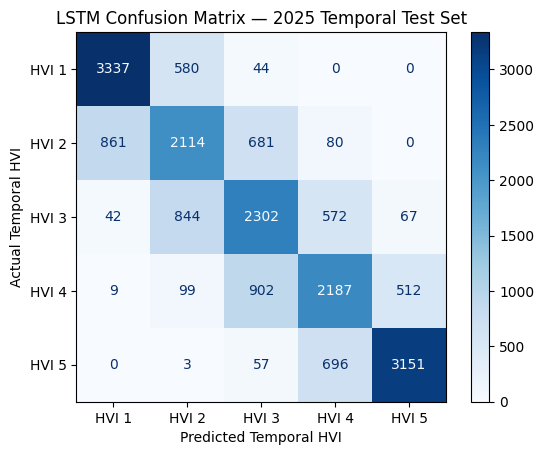

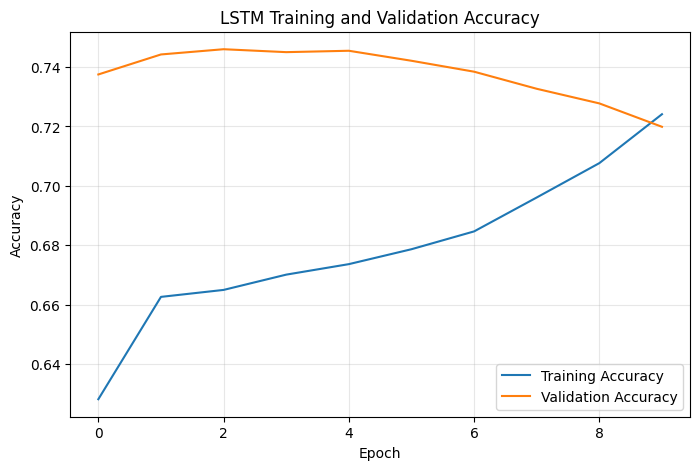

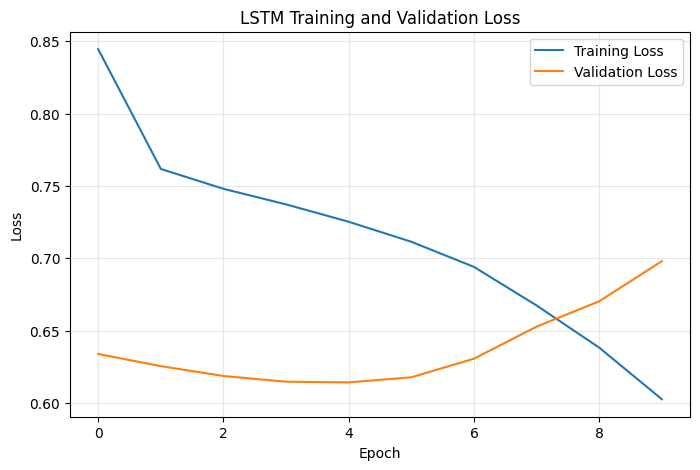


Stored LSTM results:
{'Model': 'LSTM', 'N (test obs)': 19140, 'Accuracy': 0.684, 'Macro F1': 0.681, 'Weighted F1': 0.683, 'Mean Abs Class Error': 0.338}


In [14]:
# ============================================================
# LSTM TEMPORAL PREDICTION MODEL
# Uses the previous 7 ZIP-code-day observations to predict
# the current temporal HVI class.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. PREPARE DATA FOR LSTM
# ============================================================

print("model_df shape:", model_df.shape)
print("FEATURES:", FEATURES)
print("Columns:", model_df.columns.tolist())

lstm_df = model_df.copy()

# Make sure date and ZIP code are formatted correctly
lstm_df["date"] = pd.to_datetime(lstm_df["date"])
lstm_df["zip"] = lstm_df["zip"].astype(str)

# Convert target from 1–5 scale to 0–4 scale for sparse categorical cross-entropy
lstm_df["target_lstm"] = lstm_df["temporal_hvi_target"].astype(int) - 1

# Drop missing values in features, target, date, or ZIP code
lstm_df = lstm_df.dropna(subset=FEATURES + ["target_lstm", "date", "zip"]).copy()

# Sort by ZIP code and date so sequences are chronologically ordered
lstm_df = lstm_df.sort_values(["zip", "date"]).reset_index(drop=True)

print("\nLSTM data shape:", lstm_df.shape)
print("\nTarget distribution before sequence construction:")
print(lstm_df["temporal_hvi_target"].value_counts().sort_index())


# ============================================================
# 2. TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# Train: 2020–2023 | Validation: 2024 | Test: 2025
# ============================================================

lstm_df["year"] = lstm_df["date"].dt.year

train_df_lstm = lstm_df[lstm_df["year"] <= 2023].copy()
val_df_lstm   = lstm_df[lstm_df["year"] == 2024].copy()
test_df_lstm  = lstm_df[lstm_df["year"] >= 2025].copy()

print("\nTemporal split:")
print("Train rows:", len(train_df_lstm))
print("Validation rows:", len(val_df_lstm))
print("Test rows:", len(test_df_lstm))

if len(train_df_lstm) == 0 or len(val_df_lstm) == 0 or len(test_df_lstm) == 0:
    raise ValueError(
        "Temporal split failed. Check that the dataset contains rows for "
        "training years <= 2023, validation year 2024, and test year >= 2025."
    )


# ============================================================
# 3. STANDARDIZE FEATURES
# Fit scaler only on training data to avoid data leakage.
# ============================================================

scaler_lstm = StandardScaler()

train_df_lstm[FEATURES] = scaler_lstm.fit_transform(train_df_lstm[FEATURES])
val_df_lstm[FEATURES]   = scaler_lstm.transform(val_df_lstm[FEATURES])
test_df_lstm[FEATURES]  = scaler_lstm.transform(test_df_lstm[FEATURES])


# ============================================================
# 4. CREATE 7-DAY SEQUENCES
# X = previous 7 ZIP-code-day observations
# y = current temporal HVI class
# ============================================================

LOOKBACK = 7

def create_sequences(df, features, target_col, lookback=7):
    X_sequences = []
    y_sequences = []
    row_dates = []
    row_zips = []

    df = df.sort_values(["zip", "date"]).copy()

    for zip_code, group in df.groupby("zip"):
        group = group.sort_values("date").copy()

        if len(group) <= lookback:
            continue

        X_values = group[features].values
        y_values = group[target_col].values
        dates = group["date"].values

        for i in range(lookback, len(group)):
            # Previous 7 days predict the current day's temporal HVI class
            X_sequences.append(X_values[i - lookback:i])
            y_sequences.append(y_values[i])
            row_dates.append(dates[i])
            row_zips.append(zip_code)

    return np.array(X_sequences), np.array(y_sequences), row_dates, row_zips


X_train_lstm, y_train_lstm, train_dates, train_zips = create_sequences(
    train_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

X_val_lstm, y_val_lstm, val_dates, val_zips = create_sequences(
    val_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

X_test_lstm, y_test_lstm, test_dates, test_zips = create_sequences(
    test_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

print("\nSequence shapes:")
print("X_train_lstm:", X_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)

print("\nSequence target distribution, test set:")
print(pd.Series(y_test_lstm).value_counts().sort_index())

if X_train_lstm.shape[0] == 0 or X_val_lstm.shape[0] == 0 or X_test_lstm.shape[0] == 0:
    raise ValueError(
        "One of the LSTM sequence sets has 0 rows. "
        "Check the date coverage within each ZIP code or lower LOOKBACK."
    )


# ============================================================
# 5. BUILD FINAL LSTM MODEL
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)

n_timesteps = X_train_lstm.shape[1]
n_features = X_train_lstm.shape[2]
n_classes = 5

lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(n_classes, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


# ============================================================
# 6. TRAIN FINAL LSTM MODEL
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 7. EVALUATE FINAL LSTM MODEL
# ============================================================

lstm_probs = lstm_model.predict(X_test_lstm)
lstm_preds = np.argmax(lstm_probs, axis=1)

print("\nLSTM Classification Report")
print(
    classification_report(
        y_test_lstm,
        lstm_preds,
        labels=[0, 1, 2, 3, 4],
        target_names=["HVI 1", "HVI 2", "HVI 3", "HVI 4", "HVI 5"],
        zero_division=0
    )
)

lstm_accuracy = accuracy_score(y_test_lstm, lstm_preds)
lstm_macro_f1 = f1_score(y_test_lstm, lstm_preds, average="macro", zero_division=0)
lstm_weighted_f1 = f1_score(y_test_lstm, lstm_preds, average="weighted", zero_division=0)
lstm_mean_abs_class_error = mean_absolute_error(y_test_lstm + 1, lstm_preds + 1)

print("LSTM Accuracy:", round(lstm_accuracy, 3))
print("LSTM Macro F1:", round(lstm_macro_f1, 3))
print("LSTM Weighted F1:", round(lstm_weighted_f1, 3))
print("LSTM Mean Absolute Class Error:", round(lstm_mean_abs_class_error, 3))


# ============================================================
# 8. LSTM CONFUSION MATRIX
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test_lstm + 1,
    lstm_preds + 1,
    labels=[1, 2, 3, 4, 5],
    display_labels=["HVI 1", "HVI 2", "HVI 3", "HVI 4", "HVI 5"],
    cmap="Blues"
)

plt.title("LSTM Confusion Matrix — 2025 Temporal Test Set")
plt.xlabel("Predicted Temporal HVI")
plt.ylabel("Actual Temporal HVI")
plt.show()


# ============================================================
# 9. TRAINING HISTORY PLOTS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 10. STORE LSTM RESULTS FOR FINAL MODEL COMPARISON
# ============================================================

lstm_results = {
    "Model": "LSTM",
    "N (test obs)": len(y_test_lstm),
    "Accuracy": round(lstm_accuracy, 3),
    "Macro F1": round(lstm_macro_f1, 3),
    "Weighted F1": round(lstm_weighted_f1, 3),
    "Mean Abs Class Error": round(lstm_mean_abs_class_error, 3)
}

print("\nStored LSTM results:")
print(lstm_results)

## Chunk 2 Notes
This chunk may be deleted for final blog, note to self to come back.

This chunk puts Random Forest, XGBoost, and the LSTM on the same temporal evaluation setup. Earlier, the baseline models used a random test split, while the LSTM used a time-based split. This chunk fixes that by retraining Random Forest and XGBoost on the same training years and evaluating them on the same test year as the LSTM.

The goal is to make the comparison fairer: if all models train on earlier years and test on later observations, how do the non-temporal tabular models compare to the temporal LSTM? This matters because the project is about predicting daily heat vulnerability over time, so the models should be judged on whether they generalize forward rather than whether they perform well on randomly mixed observations.

In [15]:
# ============================================================
# CHUNK 2: TEMPORAL-SPLIT TABULAR BASELINES
# Random Forest and XGBoost trained on earlier years and tested on 2025.
#
# Note:
# These are temporal-split baselines, but they are still single-day
# tabular models. They use one flat ZIP-code-day row to predict that
# same day's temporal HVI class.
#
# The LSTM, by contrast, uses the previous 7 ZIP-code-day observations
# to predict the current temporal HVI class. Therefore, this chunk is a
# strong baseline comparison, but not a perfect input-equivalent comparison.
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error


# ============================================================
# 1. USE THE SAME TEMPORAL SPLIT AS THE LSTM SECTION
# Train: 2020–2023 | Validation: 2024 | Test: 2025
# ============================================================

X_train_temporal = train_df_lstm[FEATURES]
y_train_temporal = train_df_lstm["target_lstm"]

X_val_temporal = val_df_lstm[FEATURES]
y_val_temporal = val_df_lstm["target_lstm"]

X_test_temporal = test_df_lstm[FEATURES]
y_test_temporal = test_df_lstm["target_lstm"]

print("Temporal tabular split:")
print("Train rows:", len(X_train_temporal))
print("Validation rows:", len(X_val_temporal))
print("Test rows:", len(X_test_temporal))

print("\nTest target distribution, 0–4 scale:")
print(y_test_temporal.value_counts().sort_index())


# ============================================================
# 2. TRAIN RANDOM FOREST TEMPORAL-SPLIT BASELINE
# ============================================================

rf_temporal = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_temporal.fit(X_train_temporal, y_train_temporal)
rf_temporal_preds = rf_temporal.predict(X_test_temporal)


# ============================================================
# 3. TRAIN XGBOOST TEMPORAL-SPLIT BASELINE
# ============================================================

xgb_temporal = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9
)

xgb_temporal.fit(
    X_train_temporal,
    y_train_temporal,
    eval_set=[(X_val_temporal, y_val_temporal)],
    verbose=False
)

xgb_temporal_preds = xgb_temporal.predict(X_test_temporal)


# ============================================================
# 4. COMPUTE SHARED METRICS
# ============================================================

def model_metrics(y_true, y_pred, model_name, n_obs):
    return {
        "Model": model_name,
        "N (test obs)": n_obs,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Mean Absolute Class Error": mean_absolute_error(y_true + 1, y_pred + 1)
    }


temporal_comparison_table = pd.DataFrame([
    model_metrics(
        y_test_temporal,
        rf_temporal_preds,
        "Random Forest — single-day temporal split",
        len(y_test_temporal)
    ),
    model_metrics(
        y_test_temporal,
        xgb_temporal_preds,
        "XGBoost — single-day temporal split",
        len(y_test_temporal)
    ),
    model_metrics(
        y_test_lstm,
        lstm_preds,
        "LSTM — 7-day sequence temporal split",
        len(y_test_lstm)
    )
])

temporal_comparison_table = temporal_comparison_table.set_index("Model").round(3)

print("\n=== Temporal-Split Baseline Comparison ===")
print(temporal_comparison_table)

temporal_comparison_table

Temporal tabular split:
Train rows: 81840
Validation rows: 20460
Test rows: 20295

Test target distribution, 0–4 scale:
target_lstm
0    4404
1    3989
2    4038
3    3860
4    4004
Name: count, dtype: int64

=== Temporal-Split Baseline Comparison ===
                                           N (test obs)  Accuracy  Macro F1  \
Model                                                                         
Random Forest — single-day temporal split         20295     0.988     0.988   
XGBoost — single-day temporal split               20295     0.974     0.974   
LSTM — 7-day sequence temporal split              19140     0.684     0.681   

                                           Weighted F1  \
Model                                                    
Random Forest — single-day temporal split        0.988   
XGBoost — single-day temporal split              0.974   
LSTM — 7-day sequence temporal split             0.683   

                                           Mean Absolute Clas

,N (test obs),Accuracy,Macro F1,Weighted F1,Mean Absolute Class Error
Model,,,,,
Random Forest — single-day temporal split,20295,0.988,0.988,0.988,0.012
XGBoost — single-day temporal split,20295,0.974,0.974,0.974,0.026
LSTM — 7-day sequence temporal split,19140,0.684,0.681,0.683,0.338


## Chunk 3 Notes: A final, more fine LSTM model

High-level explanation

This chunk contains the final LSTM model for predicting daily ZIP-code-level temporal heat vulnerability. It takes the cleaned dataset, restructures it into time-based sequences, trains the LSTM, and evaluates whether recent conditions can classify the current temporal HVI category. The model uses seven inputs: 311 complaint counts, maximum temperature, tree count, population density, population, fountain access, and gas therm usage, to predict one of five temporal HVI classes.

Conceptually, this chunk translates the project’s main argument into the modeling pipeline. Since the official HVI is static, the LSTM uses recent daily observations to estimate how vulnerability may shift over time. Rather than treating each ZIP-code-day as a separate snapshot, the model learns from prior sequences of ZIP-code-level conditions, which makes it better aligned with the goal of building a dynamic heat vulnerability prediction tool.

In [16]:
# CHUNK 3

# ============================================================
# FINAL LSTM MODEL FOR TEMPORAL HEAT VULNERABILITY PREDICTION
# Uses previous 7 ZIP-code-day observations to predict the
# current temporal HVI class.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. DEFINE FEATURES AND TARGET
# ============================================================

FEATURES = [
    "call_count",
    "max_temp",
    "tree_count",
    "population_density",
    "population",
    "fountains",
    "gas_therms"
]

TARGET = "temporal_hvi_target"

lstm_df = model_df.copy()

lstm_df["date"] = pd.to_datetime(lstm_df["date"])
lstm_df["zip"] = lstm_df["zip"].astype(str)
lstm_df["year"] = lstm_df["date"].dt.year

# Convert target from 1–5 to 0–4 for sparse categorical cross-entropy
lstm_df["target_lstm"] = lstm_df[TARGET].astype(int) - 1

# Keep only complete rows
lstm_df = lstm_df.dropna(subset=FEATURES + ["target_lstm", "date", "zip"]).copy()

# Sort observations by ZIP code and date
lstm_df = lstm_df.sort_values(["zip", "date"]).reset_index(drop=True)

print("Final LSTM dataset shape:", lstm_df.shape)
print("\nFull target distribution, 1–5 scale:")
print(lstm_df[TARGET].value_counts().sort_index())


# ============================================================
# 3. TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# Train: 2020–2023 | Validation: 2024 | Test: 2025
# ============================================================

train_df_lstm = lstm_df[lstm_df["year"] <= 2023].copy()
val_df_lstm   = lstm_df[lstm_df["year"] == 2024].copy()
test_df_lstm  = lstm_df[lstm_df["year"] >= 2025].copy()

print("\nTemporal split:")
print("Train rows:", len(train_df_lstm))
print("Validation rows:", len(val_df_lstm))
print("Test rows:", len(test_df_lstm))

if len(train_df_lstm) == 0 or len(val_df_lstm) == 0 or len(test_df_lstm) == 0:
    raise ValueError(
        "Temporal split failed. Check that the dataset contains "
        "training years <= 2023, validation year 2024, and test year >= 2025."
    )


# ============================================================
# 4. STANDARDIZE FEATURES
# The scaler is fit only on the training set to avoid data leakage.
# ============================================================

scaler_lstm = StandardScaler()

train_df_lstm[FEATURES] = scaler_lstm.fit_transform(train_df_lstm[FEATURES])
val_df_lstm[FEATURES]   = scaler_lstm.transform(val_df_lstm[FEATURES])
test_df_lstm[FEATURES]  = scaler_lstm.transform(test_df_lstm[FEATURES])


# ============================================================
# 5. CREATE SEQUENCES FOR LSTM
# X = previous 7 ZIP-code-day observations
# y = current temporal HVI class
# ============================================================

LOOKBACK = 7

def create_sequences(df, features, target_col, lookback=7):
    X_sequences = []
    y_sequences = []
    sequence_dates = []
    sequence_zips = []

    df = df.sort_values(["zip", "date"]).copy()

    for zip_code, group in df.groupby("zip"):
        group = group.sort_values("date").copy()

        if len(group) <= lookback:
            continue

        X_values = group[features].values
        y_values = group[target_col].values
        dates = group["date"].values

        for i in range(lookback, len(group)):
            X_sequences.append(X_values[i - lookback:i])
            y_sequences.append(y_values[i])
            sequence_dates.append(dates[i])
            sequence_zips.append(zip_code)

    return (
        np.array(X_sequences),
        np.array(y_sequences),
        np.array(sequence_dates),
        np.array(sequence_zips)
    )


X_train_lstm, y_train_lstm, train_dates, train_zips = create_sequences(
    train_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

X_val_lstm, y_val_lstm, val_dates, val_zips = create_sequences(
    val_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

X_test_lstm, y_test_lstm, test_dates, test_zips = create_sequences(
    test_df_lstm,
    FEATURES,
    "target_lstm",
    lookback=LOOKBACK
)

print("\nLSTM sequence shapes:")
print("Training:", X_train_lstm.shape)
print("Validation:", X_val_lstm.shape)
print("Test:", X_test_lstm.shape)

if X_train_lstm.shape[0] == 0 or X_val_lstm.shape[0] == 0 or X_test_lstm.shape[0] == 0:
    raise ValueError(
        "One of the LSTM sequence sets has 0 rows. "
        "Check date coverage within each ZIP code or lower LOOKBACK."
    )

print("\nTest sequence target distribution, 0–4 scale:")
print(pd.Series(y_test_lstm).value_counts().sort_index())


# ============================================================
# 6. BUILD FINAL LSTM MODEL
# ============================================================

n_timesteps = X_train_lstm.shape[1]
n_features = X_train_lstm.shape[2]
n_classes = 5

lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(n_classes, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


# ============================================================
# 7. TRAIN FINAL LSTM MODEL
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 8. EVALUATE FINAL LSTM MODEL
# ============================================================

lstm_probs = lstm_model.predict(X_test_lstm)
lstm_preds = np.argmax(lstm_probs, axis=1)

lstm_accuracy = accuracy_score(y_test_lstm, lstm_preds)
lstm_macro_f1 = f1_score(y_test_lstm, lstm_preds, average="macro", zero_division=0)
lstm_weighted_f1 = f1_score(y_test_lstm, lstm_preds, average="weighted", zero_division=0)
lstm_mae = mean_absolute_error(y_test_lstm + 1, lstm_preds + 1)

print("\nFinal LSTM Classification Report:")
print(
    classification_report(
        y_test_lstm,
        lstm_preds,
        labels=[0, 1, 2, 3, 4],
        target_names=["HVI 1", "HVI 2", "HVI 3", "HVI 4", "HVI 5"],
        zero_division=0
    )
)

final_lstm_results = pd.DataFrame({
    "Model": ["LSTM — 7-day sequence"],
    "N (test obs)": [len(y_test_lstm)],
    "Accuracy": [lstm_accuracy],
    "Macro F1": [lstm_macro_f1],
    "Weighted F1": [lstm_weighted_f1],
    "Mean Absolute Class Error": [lstm_mae]
}).round(3)

final_lstm_results

Final LSTM dataset shape: (122595, 20)

Full target distribution, 1–5 scale:
temporal_hvi_target
1    24520
2    24518
3    24519
4    24519
5    24519
Name: count, dtype: int64

Temporal split:
Train rows: 81840
Validation rows: 20460
Test rows: 20295

LSTM sequence shapes:
Training: (80685, 7, 7)
Validation: (19305, 7, 7)
Test: (19140, 7, 7)

Test sequence target distribution, 0–4 scale:
0    3961
1    3736
2    3827
3    3709
4    3907
Name: count, dtype: int64


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,677 (80.77 KB)

 Trainable params: 20,677 (80.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6286 - loss: 0.8385 - val_accuracy: 0.7371 - val_loss: 0.6388
Epoch 2/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6597 - loss: 0.7636 - val_accuracy: 0.7409 - val_loss: 0.6318
Epoch 3/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6664 - loss: 0.7478 - val_accuracy: 0.7470 - val_loss: 0.6236
Epoch 4/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6694 - loss: 0.7354 - val_accuracy: 0.7457 - val_loss: 0.6187
Epoch 5/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6760 - loss: 0.7248 - val_accuracy: 0.7428 - val_loss: 0.6215
Epoch 6/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6792 - loss: 0.7133 - val_accuracy: 0.7386 - val_loss: 0.6275
Epoch 7/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6853 - loss: 0.6975 - val_accuracy: 0.7371 - val_loss: 0.6398
Epoch 8/40
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6932 - loss: 0.

,Model,N (test obs),Accuracy,Macro F1,Weighted F1,Mean Absolute Class Error
0,LSTM — 7-day sequence,19140,0.68,0.675,0.677,0.347


# Chunk 4 Notes: Probably one of the most important chunks! Takes around 10min to run; heat vulnerability appears to depend on more than just the past few days; a two-week window gives the LSTM more useful temporal context.
This chunk checks whether the LSTM model is stable by testing several versions of it with different settings. Rather than depending on one model setup, it compares performance across different lookback windows, LSTM unit sizes, dropout rates, and batch sizes. This is important because our project’s main claim is that heat vulnerability is temporal: recent conditions may build on one another over several days. When we compare 3-day, 7-day, and 14-day windows, the model tests whether giving the LSTM more recent history improves its ability to classify ZIP-code-level heat vulnerability. The experiment table also makes the final model choice more defensible because it shows that the selected LSTM was chosen through systematic comparison rather than trial and error. Bianca will LOVE this!

In [17]:
# ============================================================
# CHUNK 4: LSTM ABLATION AND SENSITIVITY ANALYSIS
# Tests whether the LSTM is stable across lookback windows,
# hidden units, dropout levels, and batch sizes.
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

FEATURES = [
    "call_count",
    "max_temp",
    "tree_count",
    "population_density",
    "population",
    "fountains",
    "gas_therms"
]

TARGET = "temporal_hvi_target"

experiment_df = model_df.copy()
experiment_df["date"] = pd.to_datetime(experiment_df["date"])
experiment_df["zip"] = experiment_df["zip"].astype(str)
experiment_df["year"] = experiment_df["date"].dt.year
experiment_df["target_lstm"] = experiment_df[TARGET].astype(int) - 1

experiment_df = experiment_df.dropna(
    subset=FEATURES + ["target_lstm", "date", "zip"]
).copy()

experiment_df = experiment_df.sort_values(["zip", "date"]).reset_index(drop=True)

train_base = experiment_df[experiment_df["year"] <= 2023].copy()
val_base = experiment_df[experiment_df["year"] == 2024].copy()
test_base = experiment_df[experiment_df["year"] >= 2025].copy()

if len(train_base) == 0 or len(val_base) == 0 or len(test_base) == 0:
    raise ValueError(
        "Temporal split failed. Check that the dataset includes "
        "training years <= 2023, validation year 2024, and test year >= 2025."
    )

scaler_exp = StandardScaler()
train_base[FEATURES] = scaler_exp.fit_transform(train_base[FEATURES])
val_base[FEATURES] = scaler_exp.transform(val_base[FEATURES])
test_base[FEATURES] = scaler_exp.transform(test_base[FEATURES])


def create_sequences(df, features, target_col, lookback):
    X_sequences = []
    y_sequences = []

    df = df.sort_values(["zip", "date"]).copy()

    for zip_code, group in df.groupby("zip"):
        group = group.sort_values("date").copy()

        if len(group) <= lookback:
            continue

        X_values = group[features].values
        y_values = group[target_col].values

        for i in range(lookback, len(group)):
            # Previous lookback days predict the current day's temporal HVI class
            X_sequences.append(X_values[i - lookback:i])
            y_sequences.append(y_values[i])

    return np.array(X_sequences), np.array(y_sequences)


experiments = [
    {"lookback": 3, "units": 64, "dropout": 0.30, "batch_size": 64},
    {"lookback": 7, "units": 64, "dropout": 0.30, "batch_size": 64},
    {"lookback": 14, "units": 64, "dropout": 0.30, "batch_size": 64},
    {"lookback": 7, "units": 32, "dropout": 0.30, "batch_size": 64},
    {"lookback": 7, "units": 128, "dropout": 0.30, "batch_size": 64},
    {"lookback": 7, "units": 64, "dropout": 0.50, "batch_size": 64},
    {"lookback": 7, "units": 64, "dropout": 0.30, "batch_size": 32},
    {"lookback": 7, "units": 64, "dropout": 0.30, "batch_size": 128},
]

results = []

for i, config in enumerate(experiments, start=1):
    print(f"\nRunning experiment {i}/{len(experiments)}: {config}")

    lookback = config["lookback"]
    units = config["units"]
    dropout = config["dropout"]
    batch_size = config["batch_size"]

    X_train_exp, y_train_exp = create_sequences(
        train_base,
        FEATURES,
        "target_lstm",
        lookback
    )

    X_val_exp, y_val_exp = create_sequences(
        val_base,
        FEATURES,
        "target_lstm",
        lookback
    )

    X_test_exp, y_test_exp = create_sequences(
        test_base,
        FEATURES,
        "target_lstm",
        lookback
    )

    if X_train_exp.shape[0] == 0 or X_val_exp.shape[0] == 0 or X_test_exp.shape[0] == 0:
        print(f"Skipping experiment {i}: one sequence set has 0 rows.")
        continue

    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential([
        Input(shape=(lookback, len(FEATURES))),
        LSTM(units),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dropout(0.20),
        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history_exp = model.fit(
        X_train_exp,
        y_train_exp,
        validation_data=(X_val_exp, y_val_exp),
        epochs=25,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    val_probs = model.predict(X_val_exp, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)

    test_probs = model.predict(X_test_exp, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)

    results.append({
        "Experiment": i,
        "Lookback Window": lookback,
        "LSTM Units": units,
        "Dropout": dropout,
        "Batch Size": batch_size,
        "Validation Accuracy": accuracy_score(y_val_exp, val_preds),
        "Validation Macro F1": f1_score(y_val_exp, val_preds, average="macro", zero_division=0),
        "Test Accuracy": accuracy_score(y_test_exp, test_preds),
        "Test Macro F1": f1_score(y_test_exp, test_preds, average="macro", zero_division=0),
        "Test Weighted F1": f1_score(y_test_exp, test_preds, average="weighted", zero_division=0),
        "Test Mean Absolute Class Error": mean_absolute_error(y_test_exp + 1, test_preds + 1),
        "Epochs Trained": len(history_exp.history["loss"])
    })

experiment_results = pd.DataFrame(results).round(3)

print("\n=== LSTM Ablation and Sensitivity Results ===")
experiment_results


Running experiment 1/8: {'lookback': 3, 'units': 64, 'dropout': 0.3, 'batch_size': 64}

Running experiment 2/8: {'lookback': 7, 'units': 64, 'dropout': 0.3, 'batch_size': 64}

Running experiment 3/8: {'lookback': 14, 'units': 64, 'dropout': 0.3, 'batch_size': 64}

Running experiment 4/8: {'lookback': 7, 'units': 32, 'dropout': 0.3, 'batch_size': 64}

Running experiment 5/8: {'lookback': 7, 'units': 128, 'dropout': 0.3, 'batch_size': 64}

Running experiment 6/8: {'lookback': 7, 'units': 64, 'dropout': 0.5, 'batch_size': 64}

Running experiment 7/8: {'lookback': 7, 'units': 64, 'dropout': 0.3, 'batch_size': 32}

Running experiment 8/8: {'lookback': 7, 'units': 64, 'dropout': 0.3, 'batch_size': 128}

=== LSTM Ablation and Sensitivity Results ===


,Experiment,Lookback Window,LSTM Units,Dropout,Batch Size,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro F1,Test Weighted F1,Test Mean Absolute Class Error,Epochs Trained
0,1,3,64,0.3,64,0.743,0.743,0.678,0.674,0.677,0.349,14
1,2,7,64,0.3,64,0.747,0.747,0.680,0.676,0.679,0.345,8
2,3,14,64,0.3,64,0.760,0.760,0.693,0.692,0.693,0.330,7
3,4,7,32,0.3,64,0.748,0.748,0.682,0.679,0.681,0.340,9
4,5,7,128,0.3,64,0.744,0.744,0.677,0.676,0.679,0.349,7
5,6,7,64,0.5,64,0.751,0.751,0.685,0.682,0.685,0.335,7
6,7,7,64,0.3,32,0.746,0.745,0.671,0.667,0.670,0.351,6
7,8,7,64,0.3,128,0.747,0.747,0.684,0.681,0.683,0.335,7


# Chunk 5

This chunk compares all four models on the same 2025 temporal test set. Its purpose is to evaluate whether the LSTM performs differently from the non-temporal baseline models when all models are judged on their ability to generalize to future observations. The Decision Tree, Random Forest, and XGBoost models are evaluated on flat 2025 ZIP-code-day rows, while the LSTM is evaluated on 2025 ZIP-code-day sequences. Because the LSTM uses 7-day sequences, its test sample is smaller, and the chunk reports that difference transparently.

The chunk then computes the same metrics for each model: Accuracy, Macro F1, Weighted F1, and Mean Absolute Class Error. These metrics allow the models to be compared not only by overall correctness, but also by how well they perform across all five HVI classes and how far their mistakes are from the true class. The confusion matrices, metric bar charts, and per-class F1 plots help show where the models agree or diverge. So this kind of comparison is important for the project because it's not just about what model has the highest score, but whether the LSTM captures different vulnerability patterns than the tree-based models.

Also, Bianaca predicted this limitation with the LSTM. Because we do not have enough data, the model falls short. So she suggested to add synthethic data to simulate how it would perform with more data.

Tabular baseline test set:
Rows: 20295
Target distribution, 0–4 scale:
target_lstm
0    4404
1    3989
2    4038
3    3860
4    4004
Name: count, dtype: int64

LSTM sequence test set:
Rows: 19140
Target distribution, 0–4 scale:
0    3961
1    3736
2    3827
3    3709
4    3907
Name: count, dtype: int64

=== Final Model Comparison on 2025 Temporal Test Set ===
                            Input Type  N (test obs)  Accuracy  Macro F1  \
Model                                                                      
Random Forest   Single-day tabular row         20295     0.988     0.988   
XGBoost         Single-day tabular row         20295     0.974     0.974   
LSTM           Previous 7-day sequence         19140     0.680     0.675   

               Weighted F1  Mean Abs Class Error  
Model                                             
Random Forest        0.988                 0.012  
XGBoost              0.974                 0.026  
LSTM                 0.677                 0.347  


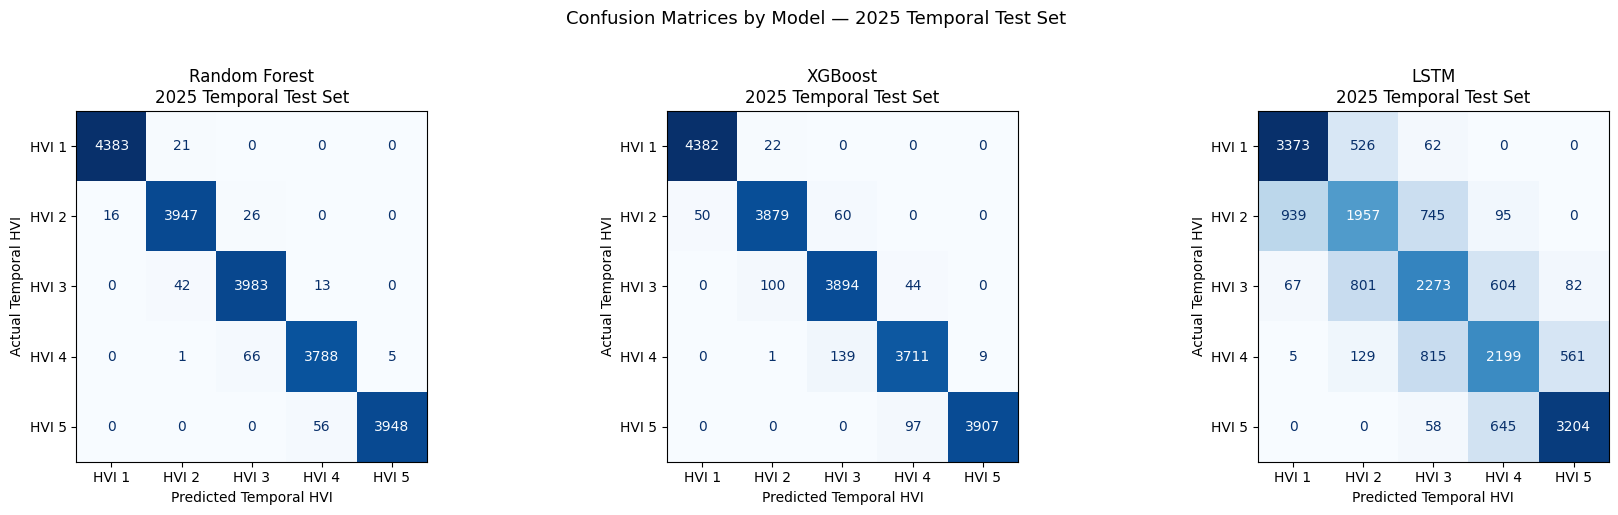

/tmp/ipykernel_13115/2123142146.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_13115/2123142146.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_13115/2123142146.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_13115/2123142146.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)


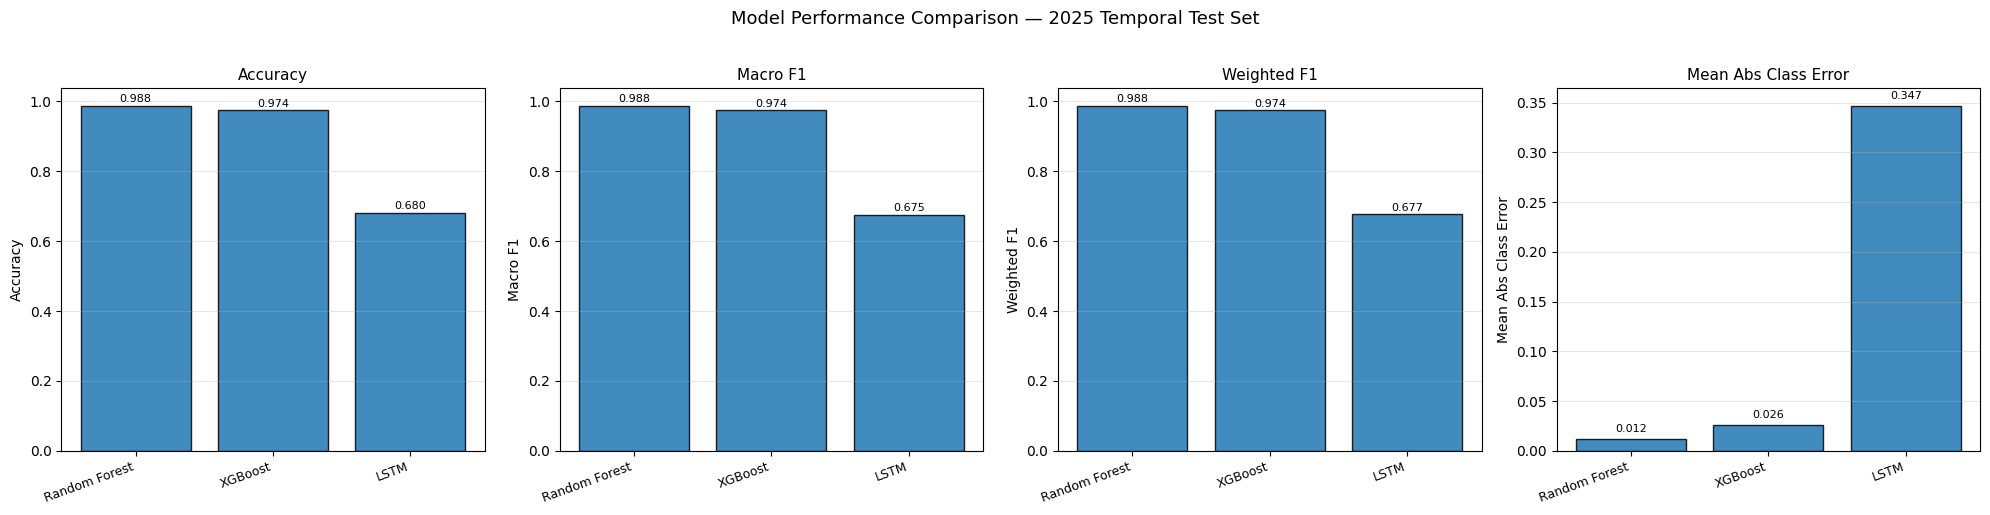

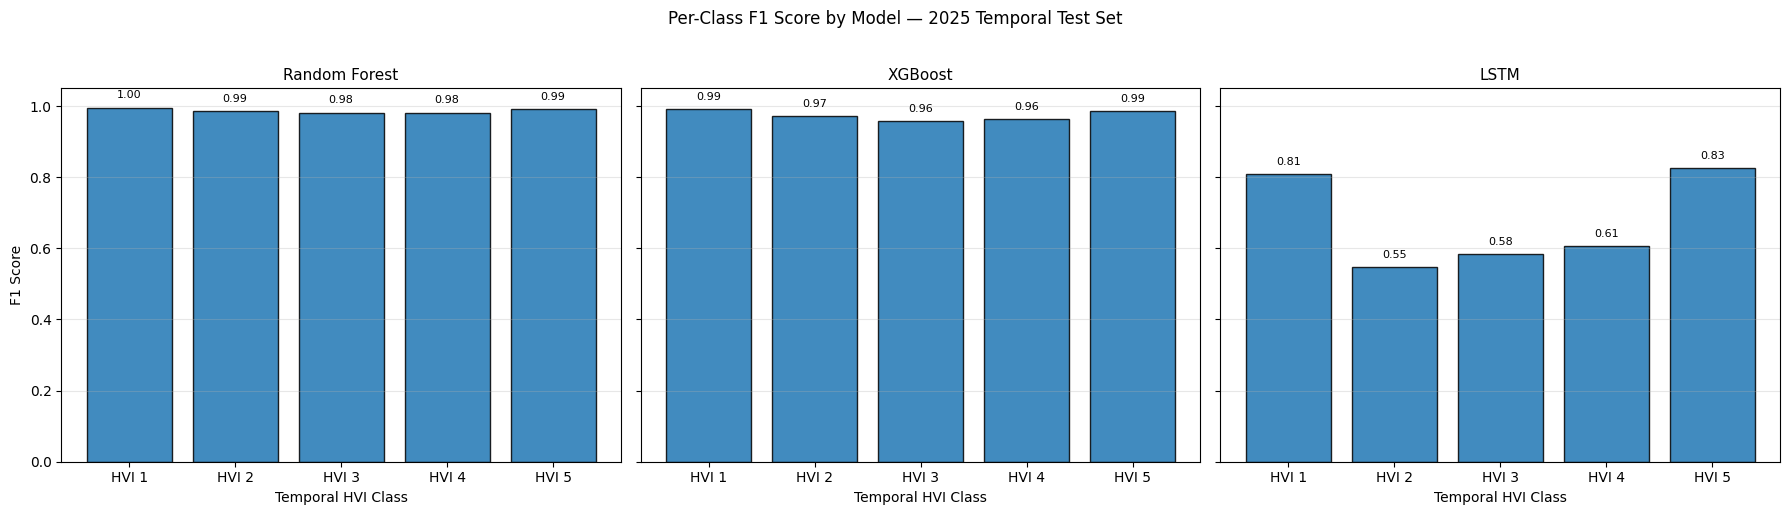


Chunk 6 complete.


In [18]:
# ============================================================
# CHUNK 5: FINAL MODEL COMPARISON AND DIAGNOSTICS
# Compares temporal-split tabular baselines with the LSTM.
#
# Random Forest and XGBoost:
#   - trained on 2020–2023
#   - tested on 2025
#   - use single-day flat ZIP-code-day rows
#
# LSTM:
#   - trained on 2020–2023 sequences
#   - tested on 2025 sequences
#   - uses previous 7 ZIP-code-day observations
#
# This is a final model comparison, but not an input-equivalent
# comparison because the tabular baselines use same-day rows while
# the LSTM uses prior-day sequences.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CONFIRM TEST SETS
# ============================================================

print("Tabular baseline test set:")
print("Rows:", len(y_test_temporal))
print("Target distribution, 0–4 scale:")
print(pd.Series(y_test_temporal).value_counts().sort_index())

print("\nLSTM sequence test set:")
print("Rows:", len(y_test_lstm))
print("Target distribution, 0–4 scale:")
print(pd.Series(y_test_lstm).value_counts().sort_index())


# ============================================================
# 2. COMPUTE FINAL METRICS
# ============================================================

def compute_metrics(y_true, y_pred, model_name, n_obs, input_type):
    return {
        "Model": model_name,
        "Input Type": input_type,
        "N (test obs)": n_obs,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Mean Abs Class Error": mean_absolute_error(y_true + 1, y_pred + 1)
    }


results = [
    compute_metrics(
        y_test_temporal,
        rf_temporal_preds,
        "Random Forest",
        len(y_test_temporal),
        "Single-day tabular row"
    ),
    compute_metrics(
        y_test_temporal,
        xgb_temporal_preds,
        "XGBoost",
        len(y_test_temporal),
        "Single-day tabular row"
    ),
    compute_metrics(
        y_test_lstm,
        lstm_preds,
        "LSTM",
        len(y_test_lstm),
        "Previous 7-day sequence"
    )
]

comparison_table = pd.DataFrame(results).set_index("Model").round(3)

print("\n=== Final Model Comparison on 2025 Temporal Test Set ===")
print(comparison_table)

comparison_table
# ============================================================
# 3. CONFUSION MATRICES
# ============================================================

model_eval_pairs = [
    ("Random Forest", y_test_temporal, rf_temporal_preds),
    ("XGBoost", y_test_temporal, xgb_temporal_preds),
    ("LSTM", y_test_lstm, lstm_preds),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_true, y_pred) in zip(axes, model_eval_pairs):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3, 4],
        display_labels=["HVI 1", "HVI 2", "HVI 3", "HVI 4", "HVI 5"],
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(f"{name}\n2025 Temporal Test Set")
    ax.set_xlabel("Predicted Temporal HVI")
    ax.set_ylabel("Actual Temporal HVI")

plt.suptitle(
    "Confusion Matrices by Model — 2025 Temporal Test Set",
    fontsize=13,
    y=1.02
)
plt.tight_layout()
plt.show()


# ============================================================
# 4. METRIC COMPARISON BAR CHART
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Macro F1",
    "Weighted F1",
    "Mean Abs Class Error"
]

plot_df = comparison_table.reset_index()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        plot_df["Model"],
        plot_df[metric],
        edgecolor="black",
        alpha=0.85
    )

    ax.set_title(metric, fontsize=11)
    ax.set_ylabel(metric)
    ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, val in zip(bars, plot_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.suptitle(
    "Model Performance Comparison — 2025 Temporal Test Set",
    fontsize=13,
    y=1.02
)
plt.tight_layout()
plt.show()


# ============================================================
# 5. PER-CLASS F1 BREAKDOWN
# ============================================================

class_labels = ["HVI 1", "HVI 2", "HVI 3", "HVI 4", "HVI 5"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, y_true, y_pred) in zip(axes, model_eval_pairs):
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3, 4],
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )

    f1_scores = [report[cls]["f1-score"] for cls in class_labels]

    bars = ax.bar(
        class_labels,
        f1_scores,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score" if ax == axes[0] else "")
    ax.set_xlabel("Temporal HVI Class")
    ax.grid(True, axis="y", alpha=0.3)

    for bar, val in zip(bars, f1_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.suptitle(
    "Per-Class F1 Score by Model — 2025 Temporal Test Set",
    fontsize=12,
    y=1.02
)
plt.tight_layout()
plt.show()

print("\nChunk 6 complete.")